In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle
plt.rcParams.update({"font.family": "serif",
                     "font.serif": ["Times New Roman"],
                     "font.size": 10,
                     "lines.linewidth": 1})
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import pandas as pd
import os
import glob
from mpl_toolkits.mplot3d import Axes3D
import re
from scipy.optimize import fsolve
from scipy.ndimage import distance_transform_edt
import warnings
from matplotlib.ticker import FuncFormatter
ROOT = os.getcwd()
OUTPUT = os.path.join(ROOT, 'output')
FIGURES = os.path.join(ROOT, 'figures')
for _p in (
    os.path.join(OUTPUT, 'Bifurcations'),
    os.path.join(OUTPUT, 'trajectories_flow'),
    os.path.join(OUTPUT, 'score'),
    os.path.join(OUTPUT, 'score_trajectories'),
    os.path.join(FIGURES, 'Paper'),
):
    os.makedirs(_p, exist_ok=True)



In [2]:
def floating_axes(ax):
    
    # Hide all default spines
    for s in ax.spines.values():
        s.set_visible(False)

    # Floating bottom axis
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_position(('axes', -0.05))

    # Floating left axis
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('axes', -0.05))
    
AMblue = plt.cm.get_cmap("viridis")(0.4)

In [3]:
directory = os.path.join(OUTPUT, 'Bifurcations')

# Line tension for change between lense & furrow

In [4]:
main_branch = pd.read_csv(os.path.join(directory, 'Main_branch.csv'), header=None)

diff = abs(main_branch[1] - (main_branch[0] - main_branch[0]**2))
idx_min = diff.idxmin()
zeta_change = main_branch.loc[idx_min, 2]

# Equations

In [5]:
def R_inv(A_C, A_M):
    return np.sqrt((1 - ((2 * A_C)/A_M - 1)**2)/A_C)/2

def dR_invdA_M(A_C, A_M):
    return - (A_M - 2 * A_C)/(A_M**2 * np.sqrt(A_M - A_C))/2

def dR_invdA_C(A_C, A_M):
    return - 1 / (2 * A_M * np.sqrt(A_M - A_C))

# Equilibrium values in case of c=0
def N_fM_sort(N_f, A_M, e):
    gamma = 1 / (1 + np.exp(-e))
    return ((A_M + N_f)*(1-gamma) +  gamma
            - np.sqrt(-4 * A_M * N_f * (1 - gamma) 
                    + ((A_M + N_f)*(1- gamma) + gamma)**2)) / (2 * (1 - gamma))

def N_dM_sort(N_f, N_d, A_M, e):
    gamma = 1 / (1 + np.exp(-e))
    return (-A_M * N_d + (A_M * N_d) / (2 * (1 - gamma)) + (N_f * N_d) / (2 * (1 - gamma)) 
            + (N_d * gamma) / (2 * (1 - gamma)) - (A_M * N_d * gamma) / (2 * (1 - gamma)) - (N_f * N_d * gamma) / (2 * (1 - gamma)) 
            - (N_d * np.sqrt(-4 * A_M * N_f * (1 - gamma) + (A_M + N_f + gamma - A_M * gamma - N_f * gamma)**2)) / (2 * (1 - gamma)))/(N_f - 1)

In [6]:
def A_M_dot(A_M, A_C, k, C0, c, N_fM, N_dM, N_f, N_d, e, t_A):
    gamma = 1 / (1 + np.exp(-e))
    entropic_contribution = np.log((A_M * ((1 - A_M) - ((Nf + N_d) - (N_fM + N_dM)))) 
                                   / ((A_M - (N_fM + N_dM)) * (1 - A_M)))
    N_M = N_fM + N_dM
    N_V = N_f + N_d - N_M
    C_M = c * N_M / A_M
    C_V = c * N_V / (1 - A_M)
    
    return 1/t_A*(entropic_contribution - 2 * k * ((R_inv(A_C,A_M) - C0 - C_M)**2 - (R_inv(A_C,1-A_M) - C0 - C_V)**2 
                                            + 2 * A_M * (R_inv(A_C,A_M) - C0 - C_M) * (dR_invdA_M(A_C, A_M)+C_M/A_M) 
                                            - 2 * (1-A_M) * (R_inv(A_C,1-A_M) - C0 - C_V) * (dR_invdA_M(A_C, 1-A_M)+C_V/(1-A_M))))

def A_C_dot(A_M, A_C, k, z, C0, c, N_fM, N_dM, N_f, N_d):
    
    N_M = N_fM + N_dM
    N_V = N_f + N_d - N_M
    C_M = c * N_M / A_M
    C_V = c * N_V / (1 - A_M)
    
    return -4 * k * (A_M * (R_inv(A_C,A_M) - C0 - C_M) * dR_invdA_C(A_C, A_M) 
                           + (1-A_M) * (R_inv(A_C,1-A_M) - C0 - C_V) * dR_invdA_C(A_C, 1-A_M))  - z*np.sqrt(np.pi)/np.sqrt(A_C)

In [7]:
def find_flow(A_M, A_C, N_f, N_d, e, z, k, C0, c, t_A):
    """ Solve N_fM_dyn and N_dM_dyn assuming equilibrium """
    
    if (A_C < A_M) & (A_C < (1 - A_M)) & (A_C>0):
        gamma = 1/(1+np.exp(-e))
        def equations(vars):
            N_fM_dyn, N_dM_dyn = vars
            N_M_dyn = N_fM_dyn + N_dM_dyn
            N_V_dyn = N_f + N_d - N_M_dyn

            C_M = c * N_M_dyn / A_M
            C_V = c * N_V_dyn / (1 - A_M)

            eq1 = -np.log((gamma * N_fM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_f - N_fM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
            eq2 = -np.log((N_dM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_d - N_dM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
            
            return [eq1, eq2]

        # Initial guess: equal partitioning
        N_fM_guess = N_fM_sort(N_f, A_M, e)
        N_dM_guess = N_dM_sort(N_f, N_d, A_M, e)
        
        N_fM_equi, N_dM_equi = fsolve(equations, [N_fM_guess, N_dM_guess])

        return A_M_dot(A_M, A_C, k, C0, c, N_fM_equi, N_dM_equi, N_f, N_d, e, t_A), A_C_dot(A_M, A_C, k, z, C0, c, N_fM_equi, N_dM_equi, N_f, N_d)
    else:
        return None, None

# Vectorize the function to apply it to arrays
vectorized_find_flow = np.vectorize(find_flow, otypes=[float, float])

# Condition for neglecting bending at the contact line

In [8]:
def Rvalue(A_i, A_C):  # R_i
    return np.sqrt(A_C / (np.pi * (1 - (2 * A_C / A_i - 1)**2)))


### l functions for the contribution from bending at the contact line

def lfurrow(A_V, A_M, A_C):  # l function for furrow shapes
    return (
        Rvalue(A_M, A_C) * (A_M / (2 * np.pi * Rvalue(A_M, A_C)**2) - 1)
        + Rvalue(A_V, A_C) * (A_V / (2 * np.pi * Rvalue(A_V, A_C)**2) - 1)
    )


def llens(A_V, A_M, A_C):  # l function for lens-like shapes
    return -lfurrow(A_V, A_M, A_C)


### f and g functions for furrows and lens-like shapes

def ffurrow(phi, rho, R_V, R_M):
    return ((R_V + rho) * np.sin(phi)) / ((R_V + rho) * np.cos(phi) - (R_M + rho))


def glens(phi, rho, R_V, R_M):
    return ((R_V - rho) * np.sin(phi)) / ((R_V - rho) * np.cos(phi) - (R_M - rho))


### Opening angles of the bent section at the contact line

def phi_from_tension_furrow(rho, C0, zeta):
    return (
        rho * (8 * np.sqrt(np.pi) * (1 - C0))
        / (-1 - C0 * rho * np.sqrt(4 * np.pi))**2
        * zeta
    )


def phi_from_tension_lens(rho, C0, zeta):
    return (
        rho * (8 * np.sqrt(np.pi) * (1 - C0))
        / (1 - C0 * rho * np.sqrt(4 * np.pi))**2
        * zeta
    )


### Condition for negligible contribution from the bending at the contact line

def equation_furrow(rho, C0, zeta, A_M, A_C):
    A_V = 1 - A_M

    R_V = Rvalue(A_V, A_C)
    R_M = Rvalue(A_M, A_C)

    phi = phi_from_tension_furrow(rho, C0, zeta)
    f = ffurrow(phi, rho, R_V, R_M)

    term1 = lfurrow(A_V, A_M, A_C)
    term2 = np.sqrt(1 / (f**2 + 1)) * ((R_M + rho) - (R_V + rho) * np.cos(phi))
    term3 = np.sqrt(f**2 / (f**2 + 1)) * ((R_V + rho) * np.sin(phi))

    return term1 - term2 - term3


def equation_lens(rho, C0, zeta, A_M, A_C):
    A_V = 1 - A_M

    R_V = Rvalue(A_V, A_C)
    R_M = Rvalue(A_M, A_C)

    phi = phi_from_tension_lens(rho, C0, zeta)
    g = glens(phi, rho, R_V, R_M)

    term1 = llens(A_V, A_M, A_C)
    term2 = np.sqrt(1 / (g**2 + 1)) * ((R_M - rho) - (R_V - rho) * np.cos(phi))
    term3 = np.sqrt(g**2 / (g**2 + 1)) * ((R_V - rho) * np.sin(phi))

    return term1 - term2 - term3

# Main section

In [9]:
# Function to split main branch at A_c = A_I - A_I**2
def split_main_branch_shape(df):
    upper_branch = df[df[1]>df[0]-df[0]**2]
    lower_branch = df[df[1]<df[0]-df[0]**2]
    return upper_branch, lower_branch

def plot_flow(ax, epsilon, kappa, zeta, C0, c, N_f, N_d, transparency = 1, legend = False):
    # Calculate and plot the flow
    # Compute flow fields
    A_M_dot_grid, A_C_dot_grid = vectorized_find_flow(A_M_grid, A_C_grid, N_f, N_d, epsilon, zeta, kappa, C0, c, t_A)
    
    # Convert possible None values to NaN for consistency
    A_M_dot_grid = np.where(np.isnan(A_M_dot_grid), np.nan, A_M_dot_grid)
    A_C_dot_grid = np.where(np.isnan(A_C_dot_grid), np.nan, A_C_dot_grid)

    ax.streamplot(A_M_grid, A_C_grid, A_M_dot_grid, A_C_dot_grid, color = 'grey', linewidth = 0.5, zorder = 1)
    
    upper_bound = np.minimum(np.where(A_M_vals <= 0.5, A_M_vals, 1 - A_M_vals), 0.5)

    ax.fill_between(A_M_vals, sphere, upper_bound, color='grey', alpha = 0.5, zorder = 1)
    
    # Plot and nullclines
    A_M_dot_contour = ax.contour(A_M_grid, A_C_grid, A_M_dot_grid, levels=0, colors=AMblue, zorder = 3)
    A_C_dot_contour = ax.contour(A_M_grid, A_C_grid, A_C_dot_grid, levels=0, colors='black', zorder = 3)
    
    # Add black diagonal lines
    ax.plot(np.linspace(0, 0.5, 1000), np.linspace(0, 0.5, 1000), linewidth=0.5, color='black')
    ax.plot(np.linspace(0.5, 1, 1000), 1 - np.linspace(0.5, 1, 1000), linewidth=0.5, color='black')
    ax.plot(np.linspace(0, 1, 1000), np.zeros(1000), linewidth=0.5, color ='black')
    
    # Manually create legend handles
    legend_handles = [
    Line2D([0], [0], color=plt.cm.viridis(0.1), linestyle='-', label=r'$\dot{A}_I=0$'),
    Line2D([0], [0], color=plt.cm.viridis(0.7), linestyle='-', label=r'$\dot{A}_c=0$'),
    ]
    if legend:
        # Add the legend
        ax.legend(handles=legend_handles, loc="upper right")
        
    ax.set_xlabel('Main area $A_M/A$', fontweight = 'bold')
    ax.set_ylabel('Ring area $A_C/A$', fontweight = 'bold')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 0.5])
    floating_axes(ax)
    ax.set_aspect(2)
    
def plot_FP(branch, ax, zeta):
    min_diff_idx = (branch[2] - zeta).abs().idxmin()
    row = branch.loc[min_diff_idx]
    A_M_FP, A_C_FP, stability = row[0], row[1], row[3]

    # Plot based on stability
    if stability == 2:
        ax.scatter(A_M_FP, A_C_FP, marker='o', color='black', edgecolor = 'black', lw=0.5, s=40, zorder=3)
    elif stability == 1:
        ax.scatter(A_M_FP, A_C_FP, marker=MarkerStyle('o', fillstyle='left'), color='black', edgecolor='black', lw=0.5, s=40, zorder=3)
        ax.scatter(A_M_FP, A_C_FP, marker=MarkerStyle('o', fillstyle='right'), color='white', edgecolor='black', lw=0.5, s=40, zorder=3)
    elif stability == 0:
        ax.scatter(A_M_FP, A_C_FP, marker='o', color='white', edgecolor = 'black', lw=0.5, s=40, zorder=3)

# FPs

In [10]:
# Function to split branches at A_M=A_val/2
def split_side_branch(df):
    left_branch = df[df[0]<0.5]
    right_branch = df[df[0]>0.5]
    return left_branch, right_branch

# Function to split main branch at A_c = A_M - A_M**2
def split_main_branch_shape(df):
    upper_branch = df[df[1]>df[0]-df[0]**2]
    lower_branch = df[df[1]<df[0]-df[0]**2]
    return upper_branch, lower_branch

# Function to split main branch at maximum in zeta
def split_main_branch(df):
    max_index = df[2].idxmax()
    max_value = df.loc[max_index, 1]
    upper_branch = df[df[1]>=max_value]
    lower_branch = df[df[1]<max_value]
    return upper_branch, lower_branch

In [11]:
# Load main and side branches
main_branch = pd.read_csv(os.path.join(directory, 'Main_branch.csv'), header=None)
side_branch_1 = pd.read_csv(os.path.join(directory, 'Side_branch_1.csv'), header=None)
side_branch_2 = pd.read_csv(os.path.join(directory, 'Side_branch_2.csv'), header=None)

# Split branches
main_branch_upper, main_branch_lower = split_main_branch_shape(main_branch)
side_branch_1_left, side_branch_1_right = split_side_branch(side_branch_1)
side_branch_2_left, side_branch_2_right = split_side_branch(side_branch_2)

## Parameters and flow grid

In [12]:
asize = 1/200 # The free energy is rescaled by a/A in Matlab
rho = 1/(3*np.sqrt(4*np.pi))

# Create a formatter that divides by zeta_change
def zeta_formatter(x, pos):
    return f"{x / zeta_change:.2f}"

kappa = 20*4*np.pi
zeta = 7/3*zeta_change
C0 = 0.4
c = 0
epsilon = -1
N = 1/2
Nf = N/2
Nd = N/2
t_A = 1/5

A_M_vals = np.linspace(0, 1, 200)
A_C_vals = np.linspace(0, 0.5, 200)

A_M_grid, A_C_grid = np.meshgrid(A_M_vals, A_C_vals)

# Masking invalid geometries
mask = (A_C_grid > 0) & (A_C_grid < A_M_grid) & (A_C_grid < (1 - A_M_grid))

# Perfect sphere condition
sphere = A_M_vals - A_M_vals**2 # RuntimeWarning due to forbidden geometries (A_cont < 0 | A_C > A_M | A_C > A - A_M)

## Uncurved particles

C:\Users\lenovo\AppData\Local\Temp/ipykernel_11852/3253984582.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt(A_C / (np.pi * (1 - (2 * A_C / A_i - 1)**2)))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_11852/3253984582.py:2: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(A_C / (np.pi * (1 - (2 * A_C / A_i - 1)**2)))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_11852/3253984582.py:2: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(A_C / (np.pi * (1 - (2 * A_C / A_i - 1)**2)))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_11852/3253984582.py:25: RuntimeWarning: invalid value encountered in divide
  return ((R_V - rho) * np.sin(phi)) / ((R_V - rho) * np.cos(phi) - (R_M - rho))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_11852/3253984582.py:9: RuntimeWarning: invalid value encountered in divide
  Rvalue(A_M, A_C) * (A_M / (2 * np.pi * Rvalue(A_M, A_C)**2) - 1)
C:\Users\lenovo\AppData\Local\Temp/ipykernel_11852/3253984582.p

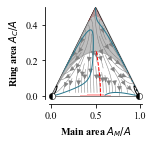

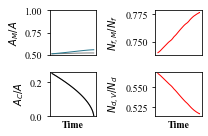

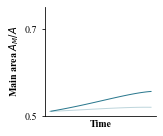

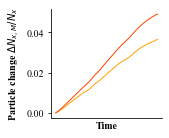

In [15]:
fig_flow = plt.figure(figsize=(1.7, 1.7))
ax_flow = fig_flow.add_subplot(111)

plot_flow(ax_flow, epsilon, kappa*asize, zeta*asize, C0, c, Nf, Nd)
plot_FP(side_branch_2_left, ax_flow, zeta)
plot_FP(side_branch_2_right, ax_flow, zeta)

# Evaluate conditions for neglecting the bending at the contact line
Z_lens = equation_lens(rho, C0, 7/3, A_M_grid, A_C_grid)
Z_furrow = equation_furrow(rho, C0, 7/3, A_M_grid, A_C_grid)

mask_lens = Z_lens > 0
mask_furrow = Z_furrow > 0

ax_flow.contourf(A_M_grid, A_C_grid, mask_furrow, levels=[0.5, 1], colors = 'red', alpha=0.3, zorder = 0)
ax_flow.contourf(A_M_grid, A_C_grid, mask_lens, levels=[0.5, 1], colors = 'red', alpha=0.3, zorder = 0)

ax_flow.set_ylim(-0.02, 0.5)
ax_flow.set_xlim(-0.02, 1.02)
trajectory = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '4D_c0.00_nf0.25_main.csv'), header=None)
ax_flow.plot(trajectory[1].values, trajectory[2].values, color = 'red', linestyle='--', zorder = 4)

#Save figure
fig_flow.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_flow_N_main.svg'), format='svg', dpi=300)
plt.show(fig_flow)
plt.close(fig_flow)

#############################################################################################
# Plot trajectory
# Reference trajectory
trajectory_absence = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '2D_main.csv'), header=None)
fig, axes = plt.subplots(2, 2, figsize=(3, 2), sharex = True)

# Relative time scale
trajectory[0] = trajectory[0]/max(trajectory[0])
trajectory_absence[0] = trajectory_absence[0]/max(trajectory_absence[0])

# Remove initial equilibration of particle numbers
trajectory = trajectory.iloc[10:]

# Smooth out particle equilibration
trajectory = trajectory.iloc[::20]

axes[0,0].plot(trajectory_absence[0].values, trajectory_absence[1].values, color = 'grey')
axes[1,0].plot(trajectory_absence[0].values, trajectory_absence[2].values, color = 'grey')

axes[0,0].plot(trajectory[0].values, trajectory[1].values, color = AMblue)
axes[1,0].plot(trajectory[0].values, trajectory[2].values, color = 'black')

axes[0,1].plot(trajectory[0].values, trajectory[3].values/Nf, color = 'red')
axes[1,1].plot(trajectory[0].values, 1-trajectory[4].values/Nd, color = 'red')

axes[1,0].set_xticks([])
axes[1,0].set_xlabel('Time', fontweight='bold')
axes[1,1].set_xticks([])
axes[1,1].set_xlabel('Time', fontweight='bold')

axes[0, 0].set_ylim([0.5,1])
axes[1, 0].set_ylim([0,0.26])

axes[0, 0].set_ylabel(r'$A_M/A$', fontweight='bold')
axes[1, 0].set_ylabel(r'$A_C/A$', fontweight='bold')
axes[0, 1].set_ylabel(r'$N_{f,M}/N_f$', fontweight='bold')
axes[1,1].set_ylabel(r'$N_{d,V}/N_d$', fontweight='bold')

plt.tight_layout()

plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_large_main.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

############ One figure each
fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(trajectory[0].values, trajectory[1].values, color = AMblue)
ax.plot(trajectory_absence[0].values, trajectory_absence[1].values, color = AMblue, alpha = 0.3)
ax.set_xticks([])
ax.set_xlabel('Time', fontweight='bold')
ax.set_ylabel(r'Main area $A_M/A$', fontweight='bold')
ax.set_yticks([0.5, 0.7])
ax.set_ylim([0.5, 0.75])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_large_simple_main.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(trajectory[0].values, (trajectory[3].values-trajectory[3].values[0])/Nf, color = 'orange')
ax.plot(trajectory[0].values, (trajectory[4].values-trajectory[4].values[0])/Nd, color = 'orangered')
ax.set_xticks([])
ax.set_xlabel('Time', fontweight='bold')
ax.set_ylabel(r'Particle change $\Delta N_{x,M}/N_x$', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(FIGURES, 'Paper', 'number_trajectory_large_simple_main.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

## Curved particles

C:\Users\lenovo\AppData\Local\Temp/ipykernel_30840/152237170.py:14: RuntimeWarning: invalid value encountered in log
  eq1 = -np.log((gamma * N_fM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_f - N_fM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_30840/152237170.py:15: RuntimeWarning: invalid value encountered in log
  eq2 = -np.log((N_dM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_d - N_dM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_30840/152237170.py:23: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  N_fM_equi, N_dM_equi = fsolve(equations, [N_fM_guess, N_dM_guess])
C:\Users\lenovo\AppData\Local\Temp/ipykernel_30840/3253984582.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt(A_C / (np.pi * (1 - (2

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\lenovo\\Documents\\Masterarbeit\\Programming_final_folder\\output\\trajectories_flow\\4D_c0.45_nf0.05.csv'

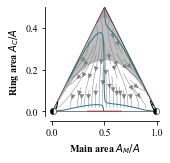

In [31]:
N = 1/10
Nf = N/2
Nd = N/2
c = 0.45

fig_flow = plt.figure(figsize=(2, 2))
ax_flow = fig_flow.add_subplot(111)

plot_flow(ax_flow, epsilon, kappa*asize, zeta*asize, C0, c, Nf, Nd)
plot_FP(side_branch_2_left, ax_flow, zeta)
plot_FP(side_branch_2_right, ax_flow, zeta)

# Evaluate conditions for neglecting the bending at the contact line
Z_lens = equation_lens(rho, C0, 7/3, A_M_grid, A_C_grid)
Z_furrow = equation_furrow(rho, C0, 7/3, A_M_grid, A_C_grid)

mask_lens = Z_lens > 0
mask_furrow = Z_furrow > 0

ax_flow.contourf(A_M_grid, A_C_grid, mask_furrow, levels=[0.5, 1], colors = 'red', alpha=0.3, zorder = 0)
ax_flow.contourf(A_M_grid, A_C_grid, mask_lens, levels=[0.5, 1], colors = 'red', alpha=0.3, zorder = 0)

ax_flow.set_ylim(-0.02, 0.5)
ax_flow.set_xlim(-0.02, 1.02)
trajectory = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '4D_c0.45_nf0.05.csv'), header=None)
ax_flow.plot(trajectory[1].values, trajectory[2].values, color = 'red', linestyle = '--', zorder = 4)

#Save figure
fig_flow.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_flow_c_0.45.svg'), format='svg', dpi=300)
plt.show(fig_flow)
plt.close(fig_flow)

#############################################################################################
# Plot trajectory
# Reference trajectory
trajectory_absence = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '2D.csv'), header=None)
fig, axes = plt.subplots(2, 2, figsize=(3, 2), sharex = True)

# Relative time scale
max_time = max(trajectory[0])
trajectory[0] = trajectory[0]/max_time
trajectory_absence[0] = trajectory_absence[0]/max(trajectory_absence[0])

# Remove initial equilibration of particle numbers
trajectory = trajectory.iloc[10:]

# Smooth out particle equilibration
trajectory = trajectory.iloc[::20]

axes[0,0].plot(trajectory_absence[0].values, trajectory_absence[1].values, color = 'grey')
axes[1,0].plot(trajectory_absence[0].values, trajectory_absence[2].values, color = 'grey')

axes[0,0].plot(trajectory[0].values, trajectory[1].values, color = AMblue)
axes[1,0].plot(trajectory[0].values, trajectory[2].values, color = 'black')

axes[0,1].plot(trajectory[0].values, trajectory[3].values/Nf, color = 'red')
axes[1,1].plot(trajectory[0].values, 1-trajectory[4].values/Nd, color = 'red')

axes[1, 0].set_xticks([])
axes[1, 0].set_xlabel('Time', fontweight='bold')
axes[1,1].set_xticks([])
axes[1,1].set_xlabel('Time', fontweight='bold')

axes[0, 0].set_ylim([0.5,0.7])
axes[1, 0].set_ylim([0,0.26])

axes[0, 0].set_ylabel(r'$A_M/A$', fontweight='bold')
axes[1, 0].set_ylabel(r'$A_C/A$', fontweight='bold')
axes[0, 1].set_ylabel(r'$N_{f,M}/N_f$', fontweight='bold')
axes[1, 1].set_ylabel(r'$N_{d,V}/N_d$', fontweight='bold')

plt.tight_layout()

plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_c_0.45_main.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

############ One figure each
fig, ax = plt.subplots(1, 1, figsize=(2, 2))

# Import uncurved proteins as reference
trajectory_uncurved = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '4D_c0.00_nf0.05.csv'), header=None)
trajectory_uncurved[0] = trajectory_uncurved[0]/max_time

ax.plot(trajectory[0].values, trajectory[1].values, color = AMblue)
ax.plot(trajectory_uncurved[0].values, trajectory_uncurved[1].values, color = AMblue, alpha = 0.3)
ax.set_xticks([])
ax.set_xlabel('Time', fontweight='bold')
ax.set_yticks([0.5, 0.6])
ax.set_ylim([0.5, 0.65])
ax.set_ylabel(r'Main area $A_M/A$', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_c_0.45_simple_main.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(trajectory[0].values, trajectory[3].values/Nf, color = 'orange', label = r'$N_{f,M}/N_f$')
ax.plot(trajectory[0].values, 1-trajectory[4].values/Nd, color = 'orangered', label = r'$N_{d,V}/N_d$')
ax.plot(trajectory_uncurved[0].values, trajectory_uncurved[3].values/Nf, color = 'orange', alpha = 0.3)
ax.plot(trajectory_uncurved[0].values, 1-trajectory_uncurved[4].values/Nd, color = 'orangered', alpha = 0.3)
ax.set_yticks(np.round(np.array([trajectory[3].values[-1], Nd-trajectory[4].values[-1], trajectory_uncurved[3].values[-1], Nd-trajectory_uncurved[4].values[-1]])*2/N, 2))
ax.set_xticks([])
ax.set_xlabel('Time', fontweight='bold')
ax.set_ylabel(r'Particles $N_{x,i}/N_x$', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(FIGURES, 'Paper', 'number_trajectory_c_0.45_simple_main.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

# Appendix

In [ ]:
kappa = 20*4*np.pi
zeta = 5/4*zeta_change
C0 = 0.4
c = 0
epsilon = -1
N = 1/10
Nf = N/2
Nd = N/2
t_A = 1/3

In [73]:
# Function to plot a plane in zeta dimension
def plot_plane_at_x(ax, x_value):
    # Create a meshgrid
    y = np.linspace(0, 1, 1000)
    z = np.linspace(0, 0.5, 1000)
    Y, Z = np.meshgrid(y, z)

    X = np.full_like(Y, x_value)

    # Plot the surface
    ax.plot_surface(X, Y, Z, color='gray', alpha=0.3, rstride=5, cstride=5)
    
# Function to plot branches in 3D
def plot_branch_3D(branch, ax, x_value=None):
    global bp_label_added, lp_label_added
    # Identify limit points (LPs)
    lp_indices = branch.index[branch[5] == 4].tolist()
    
    # Split the branch at LPs
    split_indices = [branch.index[0]] + lp_indices + [branch.index[-1]]
    branch_segments = [branch.loc[split_indices[i]:split_indices[i+1]] for i in range(len(split_indices)-1)]

    # Stability styles
    stability_styles = {0: ':', 1: '--', 2: '-'}

    for segment in branch_segments:
        for stability, linestyle in stability_styles.items():
            subset = segment[segment[5] == stability]

            if subset.empty:
                continue
            
            # color if above or below spherical conditions
            mask = (subset[1] <= subset[0]-subset[0]**2)
            furrow = subset[mask]
            lense = subset[~mask]
            ax.plot(subset[4].values, subset[0].values, subset[1].values, linestyle=linestyle, color='black', alpha=0.8)
            
            # Plot FPs
            if x_value!=None:
                if segment[4].min() <= x_value <= segment[4].max():
                    # Scatter points for FPs
                    FP = subset.iloc[(subset[4] - x_value).abs().argmin()]

                    # Plot FPs based on stability

                    if FP[5] == 2:
                        ax.scatter(FP[4], FP[0], FP[1], marker='o', color='black', lw = 0.5, s=40, zorder=3)
                    elif FP[5] == 1:
                        ax.scatter(FP[4], FP[0], FP[1], marker=MarkerStyle('o', fillstyle='left'), color='black', edgecolor='black', lw = 0.5, s=40, zorder=2)
                        ax.scatter(FP[4], FP[0], FP[1], marker=MarkerStyle('o', fillstyle='right'), color='white', edgecolor='black', lw = 0.5, s=40, zorder=2)
                    elif FP[5] == 0:
                        ax.scatter(FP[4], FP[0], FP[1], marker='o', color='white', edgecolor='black', lw = 0.5, s=40, zorder=3)


    # Scatter points for BP and LP
    bp_points = branch[branch[5] == 3]
    lp_points = branch[(branch[5] == 4) & (branch[1]>0.01)] # Ignore "false" FPs
    
    if not bp_label_added:
        ax.scatter(bp_points[4].values, bp_points[0].values, bp_points[1].values, s=30, color=scatter_colorstyle["BP"], marker = 'd', edgecolor = 'black', label="Branching Point", zorder = 5)
        bp_label_added = True
    else:
        ax.scatter(bp_points[4].values, bp_points[0].values, bp_points[1].values, s=30, color=scatter_colorstyle["BP"], marker = 'd', edgecolor = 'black', zorder = 5)

    if not lp_label_added:
        ax.scatter(lp_points[4].values, lp_points[0].values, lp_points[1].values, s=30, color=scatter_colorstyle["LP"], marker = 'd', edgecolor = 'black', label="Limit Point", zorder = 5)
        lp_label_added = True
    else:
        ax.scatter(lp_points[4].values, lp_points[0].values, lp_points[1].values, s=30, color=scatter_colorstyle["LP"], marker = 'd', edgecolor = 'black', zorder = 5)       
        
# Functions to plot branches in 2D
def plot_branch_A_M(branch, ax, ax_flow, x_value = None, inset = False):
    # Identify limit points (LPs)
    lp_indices = branch.index[branch[5] == 4].tolist()
    
    # Split the branch at LPs
    split_indices = [branch.index[0]] + lp_indices + [branch.index[-1]]
    branch_segments = [branch.loc[split_indices[i]:split_indices[i+1]] for i in range(len(split_indices)-1)]
    
    # Stability for unstable FPs, saddles & stable FPs
    stability_styles = {0: ':', 1: '--', 2: '-'}
    
    for segment in branch_segments:
        for stability, linestyle in stability_styles.items():
            subset = segment[segment[5] == stability]

            if subset.empty:
                continue
                
            ax.plot(subset[4].values, subset[0].values, color='black', linestyle=linestyle, zorder = 1)

            # Plot FPs
            if segment[4].min() <= x_value <= segment[4].max():
                # Scatter points for FPs
                idx_closest = (subset[4] - x_value).abs().idxmin()
                FP = subset.loc[idx_closest]
                
                if inset:
                    s = 30
                else:
                    s = 40
                
                # Plot FPs based on stability
                if idx_closest == subset.index[0] or idx_closest == subset.index[-1]:
                    continue
                elif FP[5] == 2:
                    ax.scatter(x_value, FP[0], marker='o', color='black', edgecolor = 'black', lw=0.5, s=s, zorder = 3)
                    if not inset:
                        ax_flow.scatter(FP[0], FP[1], marker='o', color='black', edgecolor = 'black', lw=0.5, s=s, zorder = 3) 
                elif FP[5] == 1:
                    ax.scatter(x_value, FP[0], marker=MarkerStyle('o', fillstyle='left'), color='black', edgecolor='black', lw=0.5, s=s, zorder=2)
                    ax.scatter(x_value, FP[0], marker=MarkerStyle('o', fillstyle='right'), color='white', edgecolor='black', lw=0.5, s=s, zorder=2)
                    if not inset:
                        ax_flow.scatter(FP[0], FP[1], marker=MarkerStyle('o', fillstyle='left'), color='black', edgecolor='black', lw=0.5, s=s, zorder=3)
                        ax_flow.scatter(FP[0], FP[1], marker=MarkerStyle('o', fillstyle='right'), color='white', edgecolor='black', lw=0.5, s=s, zorder=3)
                elif FP[5] == 0: 
                    ax.scatter(x_value, FP[0], marker='o', color='white', edgecolor = 'black', lw=0.5, s=s, zorder = 3)
                    if not inset:
                        ax_flow.scatter(FP[0], FP[1], marker='o', color='white', edgecolor = 'black', lw=0.5, s=s, zorder = 3)  
    
    if inset:
        # Scatter points for BP and LP
        bp_points = branch[branch[5] == 3]
        lp_points = branch[(branch[5] == 4) & (branch[1]>0.01)] # Ignore "false" LPs

        ax.scatter(bp_points[4].values, bp_points[0].values, s=20, color= scatter_colorstyle["BP"], marker = 'd', edgecolor = 'black', lw = 0.5, zorder = 3)
        ax.scatter(lp_points[4].values, lp_points[0].values, s=20, color= scatter_colorstyle["LP"], marker = 'd', edgecolor = 'black', lw = 0.5, zorder = 3)
    else:
        # Scatter points for BP and LP
        bp_points = branch[branch[5] == 3]
        lp_points = branch[(branch[5] == 4) & (branch[1]>0.01)] # Ignore "false" LPs

        ax.scatter(bp_points[4].values, bp_points[0].values, s=30, color= scatter_colorstyle["BP"], marker = 'd', edgecolor = 'black', lw = 0.5, zorder = 3)
        ax.scatter(lp_points[4].values, lp_points[0].values, s=30, color= scatter_colorstyle["LP"], marker = 'd', edgecolor = 'black', lw = 0.5, zorder = 3)
        
        
def plot_branch_A_C(branch, ax, x_value = None, inset = False):
    # Identify limit points (LPs)
    lp_indices = branch.index[branch[5] == 4].tolist()
    
    # Split the branch at LPs
    split_indices = [branch.index[0]] + lp_indices + [branch.index[-1]]
    branch_segments = [branch.loc[split_indices[i]:split_indices[i+1]] for i in range(len(split_indices)-1)]
    
    # Stability for unstable FPs, saddles & stable FPs
    stability_styles = {0: ':', 1: '--', 2: '-'}
    
    for segment in branch_segments:
        for stability, linestyle in stability_styles.items():
            subset = segment[segment[5] == stability]

            if subset.empty:
                continue
        
            # color if above or below spherical conditions
            mask = (subset[1] <= subset[0]-subset[0]**2)
            furrow = subset[mask]
            lense = subset[~mask]
            ax.plot(subset[4].values, subset[1].values, linestyle=linestyle, color='black', zorder = 1)
                
        # Plot FPs
        if x_value!=None:
            if segment[4].min() <= x_value <= segment[4].max():
                # Scatter points for FPs
                FP = segment.iloc[(segment[4] - x_value).abs().argmin()]

                if inset:
                    s = 30
                else:
                    s = 40

                # Plot FPs based on stability
                if FP[5] == 2:
                    ax.scatter(x_value, FP[1], marker='o', color='black', edgecolor = 'black', lw=0.5, s=s, zorder = 3) 
                elif FP[5] == 1:
                    ax.scatter(x_value, FP[1], marker=MarkerStyle('o', fillstyle='left'), color='black', edgecolor='black', lw=0.5, s=s, zorder=2)
                    ax.scatter(x_value, FP[1], marker=MarkerStyle('o', fillstyle='right'), color='white', edgecolor='black', lw=0.5, s=s, zorder=2)
                elif FP[5] == 0: 
                    ax.scatter(x_value, FP[1], marker='o', color='white', edgecolor = 'black', lw=0.5, s=s, zorder = 3)        

    if inset:
        # Scatter points for BP and LP
        bp_points = branch[branch[5] == 3]
        lp_points = branch[(branch[5] == 4) & (branch[1]>0.01)] # Ignore "false" LPs

        ax.scatter(bp_points[4].values, bp_points[1].values, s=20, color= scatter_colorstyle["BP"], marker = 'd', edgecolor = 'black', lw = 0.5, zorder = 3)
        ax.scatter(lp_points[4].values, lp_points[1].values, s=20, color= scatter_colorstyle["LP"], marker = 'd', edgecolor = 'black', lw = 0.5, zorder = 3)
    else:   
        # Scatter points for BP and LP
        bp_points = branch[branch[5] == 3]
        lp_points = branch[(branch[5] == 4) & (branch[1]>0.01)] # Ignore "false" LPs

        ax.scatter(bp_points[4].values, bp_points[1].values, s=30, color= scatter_colorstyle["BP"], marker = 'd', edgecolor = 'black', lw=0.5, zorder = 3)
        ax.scatter(lp_points[4].values, lp_points[1].values, s=30, color= scatter_colorstyle["LP"], marker = 'd', edgecolor = 'black', lw=0.5, zorder = 3)
        
def find_equilib(A_M, A_C, N_f, N_d, e, z, k, C0, c):
    """ Solve N_fM_dyn and N_dM_dyn assuming equilibrium """
    
    if ((A_C+1e-3) < min(A_M, 1-A_M)) and ((A_C-1e-03)>0):
        gamma = 1/(1+np.exp(-e))
        def equations(vars):
            N_fM_dyn, N_dM_dyn = vars
            N_M_dyn = N_fM_dyn + N_dM_dyn
            N_V_dyn = N_f + N_d - N_M_dyn

            C_M = c * N_M_dyn / A_M
            C_V = c * N_V_dyn / (1 - A_M)

            eq1 = -np.log((gamma * N_fM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_f - N_fM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
            eq2 = -np.log((N_dM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_d - N_dM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
            
            return [eq1, eq2]

        # Initial guess: equal partitioning
        N_fM_guess = N_fM_sort(N_f, A_M, e)
        N_dM_guess = N_dM_sort(N_f, N_d, A_M, e)

        N_fM_equi, N_dM_equi = fsolve(equations, [N_fM_guess, N_dM_guess]) # Error message for the two nullclines aligning
        return (N_fM_equi-N_fM_guess)/N_f*100, (N_dM_equi-N_dM_guess)/N_d*100
    else:
        return None, None
    
vectorized_find_equilib = np.vectorize(find_equilib, otypes=[float, float])

In [ ]:
# x-axis tick positions in absolute values
xticks = [0, zeta_change/3, 2*zeta_change/3, 3*zeta_change/3, 4*zeta_change/3]

### No particle case

In [ ]:
# Load main and side branches
main_branch = pd.read_csv(os.path.join(directory, 'Main_branch.csv'), header=None)
side_branch_1 = pd.read_csv(os.path.join(directory, 'Side_branch_1.csv'), header=None)
side_branch_2 = pd.read_csv(os.path.join(directory, 'Side_branch_2.csv'), header=None)

main_branch = main_branch[main_branch[2]<4/3*zeta_change]
side_branch_1 = side_branch_1[side_branch_1[2]<4/3*zeta_change]
side_branch_2 = side_branch_2[side_branch_2[2]<4/3*zeta_change]

# Split branches
main_branch_upper, main_branch_lower = split_main_branch_shape(main_branch)

# Convert to correct prefactor
branches = [main_branch_upper, main_branch_lower,
            side_branch_1, side_branch_2]

# Functions to plot branches in 2D
def plot_branch_A_M_simple(branch, ax):
    branch = branch[branch[2] > 0]
    
    # Stability for unstable FPs, saddles & stable FPs
    stability_styles = {0: ':', 1: '--', 2: '-'}
    
    for stability, linestyle in stability_styles.items():
        subset = branch[branch[3] == stability]
        ax.plot(subset[2].values, subset[0].values, color='grey', alpha = 0.5, linestyle=linestyle, zorder = 1) 
        
def plot_branch_A_C_simple(branch, ax):
    branch = branch[branch[2] > 0]
    
    # Stability for unstable FPs, saddles & stable FPs
    stability_styles = {0: ':', 1: '--', 2: '-'}
    
    for stability, linestyle in stability_styles.items():
        subset = branch[branch[3] == stability]

        ax.plot(subset[2].values, subset[1].values, linestyle=linestyle, color='grey', alpha = 0.5, zorder = 1)

### Plots

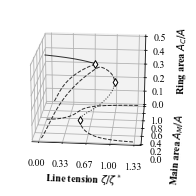

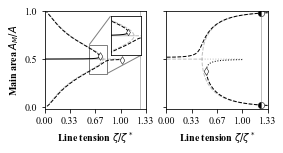

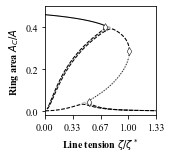

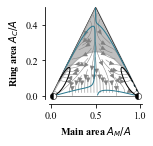

In [75]:
c=0

# Load main and side branches
branch_1 = pd.read_csv(os.path.join(directory, f'Branch_c_0_1.csv'), header=None)
branch_2 = pd.read_csv(os.path.join(directory, f'Branch_c_0_2.csv'), header=None)
branch_3 = pd.read_csv(os.path.join(directory, f'Branch_c_0_3.csv'), header=None)

branch_1[4] = branch_1[4]/asize
branch_2[4] = branch_2[4]/asize
branch_3[4] = branch_3[4]/asize

branch_1 = branch_1[branch_1[4]<4/3*zeta_change]
branch_2 = branch_2[branch_2[4]<4/3*zeta_change]
branch_3 = branch_3[branch_3[4]<4/3*zeta_change]

# Split middle branch by spherical condition
branch_2_upper, branch_2_lower = split_main_branch_shape(branch_2)

# Track if labels have been added
bp_label_added = False
lp_label_added = False

# Define filling for scatter points
scatter_colorstyle = {"BP": 'black', "LP": 'white'}

####################################################################################
# 3D bifurcation diagram
fig_3D = plt.figure(figsize=(5, 3))
ax3D = fig_3D.add_subplot(111, projection='3d')

plot_branch_3D(branch_1, ax3D)
plot_branch_3D(branch_2_upper, ax3D)
plot_branch_3D(branch_2_lower, ax3D)
plot_branch_3D(branch_3, ax3D)

# Viewing angle
ax3D.view_init(elev=20, azim=-85)

# Axis limits and labels
ax3D.set_ylim(0, 1)
ax3D.set_zlim(0, 0.5)
ax3D.set_xticks(xticks)

ax3D.set_xlabel(r"Line tension $\zeta/\zeta^*$", ha='center', fontweight='bold')
ax3D.set_ylabel('Main area $A_M/A$', ha='center', fontweight='bold', labelpad=8)
ax3D.set_zlabel('Ring area $A_C/A$', ha='center', fontweight='bold', labelpad=10)

ax3D.xaxis.set_major_formatter(FuncFormatter(zeta_formatter)) # align zeta scaling

# Save 3D plot **without labels or legend**
plt.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_c_0_3D.svg'), dpi=300, bbox_inches='tight')
plt.show()

plt.close(fig_3D)

################################################################################################
# 2D bifurcation diagrams and flow diagram FPs
figM, (axM1, axM2) = plt.subplots(1, 2, figsize=(4, 1.8), sharey=True)
figC, axC = plt.subplots(1, 1, figsize=(2,2))
fig_flow = plt.figure(figsize=(1.7, 1.7))
ax_flow = fig_flow.add_subplot(111)

plot_flow(ax_flow, epsilon, kappa*asize, zeta*asize, C0, c, Nf, Nd)

# Plot branches without particles
plot_branch_A_M_simple(main_branch_upper, axM1)
plot_branch_A_M_simple(main_branch_lower, axM2)
plot_branch_A_M_simple(side_branch_1, axM1)
plot_branch_A_M_simple(side_branch_2, axM2)

plot_branch_A_C_simple(main_branch_upper, axC)
plot_branch_A_C_simple(main_branch_lower, axC)
plot_branch_A_C_simple(side_branch_1, axC)
plot_branch_A_C_simple(side_branch_2, axC)

# Plot branches with particles
plot_branch_A_M(branch_1, axM2, ax_flow, x_value = zeta)
plot_branch_A_M(branch_2_upper, axM1, ax_flow, x_value = zeta)
plot_branch_A_M(branch_2_lower, axM2, ax_flow, x_value = zeta)
plot_branch_A_M(branch_3, axM1, ax_flow, x_value = zeta)

plot_branch_A_C(branch_1, axC)
plot_branch_A_C(branch_2_upper, axC)
plot_branch_A_C(branch_2_lower, axC)
plot_branch_A_C(branch_3, axC)

# Plot inset
axins = inset_axes(axM1, width="30%", height="40%", loc="upper right")
plot_branch_A_M_simple(main_branch_upper, axins)
plot_branch_A_M_simple(side_branch_1, axins)
plot_branch_A_M(branch_2_upper, axins, ax_flow, x_value = zeta, inset = True)
plot_branch_A_M(branch_3, axins, ax_flow, x_value = zeta, inset = True)
axins.set_xlim(200, 280)
axins.set_ylim(0.35, 0.65)
axins.set_xticks([])
axins.set_yticks([])
axins.tick_params(labelleft=False, labelbottom=False)
mark_inset(axM1, axins, loc1=2, loc2=4, fc="none", ec="0.5")
axins.axvline(x=zeta, color='grey', alpha = 0.5, lw = 1)

# Labels and limits
axM1.set_ylabel('Main area $A_M/A$', fontweight='bold')
axM1.set_ylim(-0.02, 1)
axM1.set_xlim(0.001, 4)
axM2.set_ylim(-0.02, 1)
axM2.set_xlim(0.001, 3.5)

axC.set_ylabel('Ring area $A_C/A$', fontweight='bold')
axC.set_ylim(-0.02, 0.5)
axC.set_xlim(0.001, 3.5)


for ax in [axM1, axM2, axC]:
    ax.grid(False)
    ax.set_xlabel(r"Line tension $\zeta/\zeta^*$", fontweight='bold')
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(FuncFormatter(zeta_formatter)) # align zeta scaling

axM1.axvline(x=zeta, color='grey', alpha = 0.5)
axM2.axvline(x=zeta, color='grey', alpha = 0.5)

ax_flow.set_ylim(-0.02, 0.5)
ax_flow.set_xlim(-0.02, 1.02)

#Save figures
figM.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_AM_c_0_2D.svg'), dpi=300, bbox_inches='tight')
figC.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_AC_c_0_2D.svg'), dpi=300, bbox_inches='tight')
fig_flow.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_flow_c_0.svg'), format='svg', dpi=300)
plt.show(figM)
plt.show(figC)
plt.show(fig_flow)
plt.close(figM)
plt.close(figC)
plt.close(fig_flow)

### Curved particles

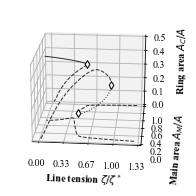

C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/152237170.py:14: RuntimeWarning: invalid value encountered in log
  eq1 = -np.log((gamma * N_fM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_f - N_fM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/152237170.py:15: RuntimeWarning: invalid value encountered in log
  eq2 = -np.log((N_dM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_d - N_dM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/152237170.py:23: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  N_fM_equi, N_dM_equi = fsolve(equations, [N_fM_guess, N_dM_guess])


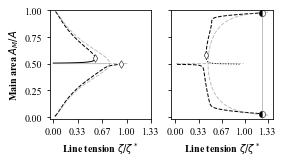

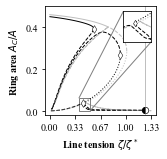

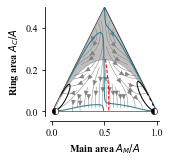

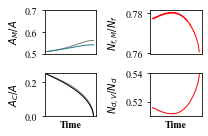

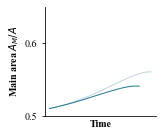

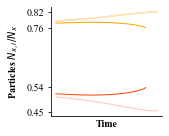

C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/3387796328.py:250: RuntimeWarning: invalid value encountered in log
  eq1 = -np.log((gamma * N_fM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_f - N_fM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/3387796328.py:251: RuntimeWarning: invalid value encountered in log
  eq2 = -np.log((N_dM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_d - N_dM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/3387796328.py:259: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  N_fM_equi, N_dM_equi = fsolve(equations, [N_fM_guess, N_dM_guess]) # Error message for the two nullclines aligning


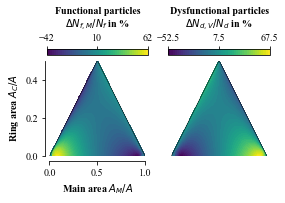

In [ ]:
N = 1/10
Nf = N/2
Nd = N/2
c = 0.45

# Load main and side branches
branch_1 = pd.read_csv(os.path.join(directory, f'Branch_c_0.45_1.csv'), header=None)
branch_2 = pd.read_csv(os.path.join(directory, f'Branch_c_0.45_2.csv'), header=None)
branch_3 = pd.read_csv(os.path.join(directory, f'Branch_c_0.45_3.csv'), header=None)

branch_1[4] = branch_1[4]/asize
branch_2[4] = branch_2[4]/asize
branch_3[4] = branch_3[4]/asize

branch_1 = branch_1[branch_1[4]<4/3*zeta_change]
branch_2 = branch_2[branch_2[4]<4/3*zeta_change]
branch_3 = branch_3[branch_3[4]<4/3*zeta_change]

# Convert to correct prefactor
branches = [branch_1, branch_3, branch_2]

# Split middle branch by spherical condition
branch_2_upper, branch_2_lower = split_main_branch_shape(branch_2)

# Track if labels have been added
bp_label_added = False
lp_label_added = False
# Define filling for scatter points
scatter_colorstyle = {"BP": 'black', "LP": 'white'}

####################################################################################
# 3D bifurcation diagram
fig_3D = plt.figure(figsize=(5, 3))
ax3D = fig_3D.add_subplot(111, projection='3d')

plot_branch_3D(branch_1, ax3D)
plot_branch_3D(branch_2_upper, ax3D)
plot_branch_3D(branch_2_lower, ax3D)
plot_branch_3D(branch_3, ax3D)
#plot_plane_at_x(ax3D, zeta)

# Viewing angle
ax3D.view_init(elev=20, azim=-85)

# Axis limits and labels
ax3D.set_ylim(0, 1)
ax3D.set_zlim(0, 0.5)
ax3D.set_xticks(xticks)

ax3D.xaxis.set_major_formatter(FuncFormatter(zeta_formatter)) # align zeta scaling

ax3D.set_xlabel(r"Line tension $\zeta/\zeta^*$", ha='center', fontweight='bold')
ax3D.set_ylabel('Main area $A_M/A$', ha='center', fontweight='bold', labelpad=8)
ax3D.set_zlabel('Ring area $A_C/A$', ha='center', fontweight='bold', labelpad=10)

# Save 3D plot **without labels or legend**
plt.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_c_0.45_3D.svg'), dpi=300, bbox_inches='tight')
plt.show()

plt.close(fig_3D)

################################################################################################
# 2D bifurcation diagrams and flow diagram FPs
figM, (axM1, axM2) = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
figC, axC = plt.subplots(1, 1, figsize=(2,2))
fig_flow = plt.figure(figsize=(2, 2))
ax_flow = fig_flow.add_subplot(111)

plot_flow(ax_flow, epsilon, kappa*asize, zeta*asize, C0, c, Nf, Nd)

plot_branch_A_M(branch_1, axM2, ax_flow, x_value = zeta)
plot_branch_A_M(branch_2_lower, axM2, ax_flow, x_value = zeta)
plot_branch_A_M(branch_2_upper, axM1, ax_flow, x_value = zeta)
plot_branch_A_M(branch_3, axM1, ax_flow, x_value = zeta)

plot_branch_A_C(branch_1, axC, x_value = zeta)
plot_branch_A_C(branch_2_upper, axC, x_value = zeta)
plot_branch_A_C(branch_2_lower, axC, x_value = zeta)
plot_branch_A_C(branch_3, axC, x_value = zeta)

# Plot branches without particles
plot_branch_A_M_simple(main_branch_upper, axM1)
plot_branch_A_M_simple(main_branch_lower, axM2)
plot_branch_A_M_simple(side_branch_1, axM1)
plot_branch_A_M_simple(side_branch_2, axM2)

plot_branch_A_C_simple(main_branch_upper, axC)
plot_branch_A_C_simple(main_branch_lower, axC)
plot_branch_A_C_simple(side_branch_1, axC)
plot_branch_A_C_simple(side_branch_2, axC)

# Plot insets
'''
axins = inset_axes(axM1, width="30%", height="40%", loc="upper right")
plot_branch_A_M_simple(main_branch_upper, axins)
plot_branch_A_M_simple(side_branch_1, axins)
plot_branch_A_M(branch_2_upper, axins, ax_flow, 'grey', x_value = zeta, inset = True)
plot_branch_A_M(branch_3, axins, ax_flow, 'grey', x_value = zeta, inset = True)
axins.set_xlim(170, 270)
axins.set_ylim(0.39, 0.65)
axins.set_xticks([])
axins.set_yticks([])
axins.tick_params(labelleft=False, labelbottom=False)
mark_inset(axM1, axins, loc1=2, loc2=4, fc="none", ec="0.5")
axins.axvline(x=zeta, color='grey', alpha = 0.5, lw = 1)
'''

'''
axins = inset_axes(axC, width="30%", height="40%", loc="upper right")
plot_branch_A_C_simple(main_branch_upper, axins)
plot_branch_A_C_simple(side_branch_1, axins)
plot_branch_A_C(branch_2_upper, axins, x_value = zeta, inset = True)
plot_branch_A_C(branch_3, axins, x_value = zeta, inset = True)
axins.set_xlim(170, 270)
axins.set_ylim(0.35, 0.45)
axins.set_xticks([])
axins.set_yticks([])
axins.tick_params(labelleft=False, labelbottom=False)
mark_inset(axC, axins, loc1=2, loc2=3, fc="none", ec="0.5")
axins.axvline(x=zeta, color='grey', alpha = 0.5, lw = 1)
'''

axins2 = inset_axes(axC, width="25%", height="28%", loc="upper right") 
plot_branch_A_C_simple(main_branch_lower, axins2)
plot_branch_A_C_simple(side_branch_2, axins2)
plot_branch_A_C(branch_2_lower, axins2, x_value = zeta, inset = True)
plot_branch_A_C(branch_1, axins2, x_value = zeta, inset = True)
axins2.set_xlim(130, 180)
axins2.set_ylim(0, 0.06)
axins2.set_xticks([])
axins2.set_yticks([])
axins2.tick_params(labelleft=False, labelbottom=False)
mark_inset(axC, axins2, loc1=2, loc2=4, fc="none", ec="0.5")
axins2.axvline(x=zeta, color='grey', alpha = 0.5, lw = 1)

axM2.axvline(x=zeta, color='grey', alpha = 0.5)
axC.axvline(x=zeta, color='grey', alpha = 0.5)

# Labels and limits
axM1.set_ylabel('Main area $A_M/A$', fontweight='bold')
axM1.set_ylim(-0.02, 1)
axM2.set_ylim(-0.02, 1)

axC.set_ylabel('Ring area $A_C/A$', fontweight='bold')
axC.set_ylim(-0.02, 0.5)

for ax in [axM1, axM2, axC]:
    ax.grid(False)
    ax.set_xlabel(r"Line tension $\zeta/\zeta^*$", fontweight='bold')
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(FuncFormatter(zeta_formatter)) # align zeta scaling

ax_flow.set_ylim(-0.02, 0.5)
ax_flow.set_xlim(-0.02, 1.02)
trajectory = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '4D_c0.45_nf0.05.csv'), header=None)
ax_flow.plot(trajectory[1].values, trajectory[2].values, color = 'red', linestyle = '--', zorder = 4)

#Save figures
figM.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_AM_C_0.45_2D.svg'),format='svg', dpi=300, bbox_inches='tight')
figC.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_AC_C_0.45_2D.svg'), format='svg', dpi=300, bbox_inches='tight')
fig_flow.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_flow_c_0.45.svg'), format='svg', dpi=300)
plt.show(figM)
plt.show(figC)
plt.show(fig_flow)
plt.close(figM)
plt.close(figC)
plt.close(fig_flow)

#############################################################################################
# Plot trajectory
# Reference trajectory
trajectory_absence = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '2D.csv'), header=None)
fig, axes = plt.subplots(2, 2, figsize=(3, 2), sharex = True)

# Relative time scale
max_time = max(trajectory[0])
trajectory[0] = trajectory[0]/max_time
trajectory_absence[0] = trajectory_absence[0]/max(trajectory_absence[0])

# Remove initial equilibration of particle numbers
trajectory = trajectory.iloc[10:]

# Smooth out particle equilibration
trajectory = trajectory.iloc[::20]

axes[0,0].plot(trajectory_absence[0].values, trajectory_absence[1].values, color = 'grey')
axes[1,0].plot(trajectory_absence[0].values, trajectory_absence[2].values, color = 'grey')

axes[0,0].plot(trajectory[0].values, trajectory[1].values, color = AMblue)
axes[1,0].plot(trajectory[0].values, trajectory[2].values, color = 'black')

axes[0,1].plot(trajectory[0].values, trajectory[3].values/Nf, color = 'red')
axes[1,1].plot(trajectory[0].values, 1-trajectory[4].values/Nd, color = 'red')

axes[1, 0].set_xticks([])
axes[1, 0].set_xlabel('Time', fontweight='bold')
axes[1,1].set_xticks([])
axes[1,1].set_xlabel('Time', fontweight='bold')

axes[0, 0].set_ylim([0.5,0.7])
axes[1, 0].set_ylim([0,0.26])

axes[0, 0].set_ylabel(r'$A_M/A$', fontweight='bold')
axes[1, 0].set_ylabel(r'$A_C/A$', fontweight='bold')
axes[0, 1].set_ylabel(r'$N_{f,M}/N_f$', fontweight='bold')
axes[1, 1].set_ylabel(r'$N_{d,V}/N_d$', fontweight='bold')

plt.tight_layout()

plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_c_0.45.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

############ One figure each
fig, ax = plt.subplots(1, 1, figsize=(2, 2))

# Import uncurved proteins as reference
trajectory_uncurved = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '4D_c0.00_nf0.05.csv'), header=None)
trajectory_uncurved[0] = trajectory_uncurved[0]/max_time

ax.plot(trajectory[0].values, trajectory[1].values, color = AMblue)
ax.plot(trajectory_uncurved[0].values, trajectory_uncurved[1].values, color = AMblue, alpha = 0.3)
ax.set_xticks([])
ax.set_xlabel('Time', fontweight='bold')
ax.set_yticks([0.5, 0.6])
ax.set_ylim([0.5, 0.65])
ax.set_ylabel(r'Main area $A_M/A$', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_c_0.45_simple.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(trajectory[0].values, trajectory[3].values/Nf, color = 'orange', label = r'$N_{f,M}/N_f$')
ax.plot(trajectory[0].values, 1-trajectory[4].values/Nd, color = 'orangered', label = r'$N_{d,V}/N_d$')
ax.plot(trajectory_uncurved[0].values, trajectory_uncurved[3].values/Nf, color = 'orange', alpha = 0.3)
ax.plot(trajectory_uncurved[0].values, 1-trajectory_uncurved[4].values/Nd, color = 'orangered', alpha = 0.3)
ax.set_yticks(np.round(np.array([trajectory[3].values[-1], Nd-trajectory[4].values[-1], trajectory_uncurved[3].values[-1], Nd-trajectory_uncurved[4].values[-1]])*2/N, 2))
ax.set_xticks([])
ax.set_xlabel('Time', fontweight='bold')
ax.set_ylabel(r'Particles $N_{x,i}/N_x$', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(FIGURES, 'Paper', 'number_trajectory_c_0.45_simple.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

#################################################################################################
# Plot change in number equilibrium in a separate figure
fig_nu, (ax_nu1, ax_nu2) = plt.subplots(1, 2, figsize=(4, 2.2), sharey = True)  # New figure with requested size

N_fM_grid, N_dM_grid = vectorized_find_equilib(A_M_grid, A_C_grid, Nf, Nd, epsilon, zeta*asize, kappa*asize, C0, c) #the free energy is rescaled by a/A
############### The warning comes for small A_c, A_i = 0,1: numerical solutions are not found (runs into invalid regions)

# Convert possible None values to NaN for consistency
N_fM_grid = np.where(np.isnan(N_fM_grid), np.nan, N_fM_grid)
N_dM_grid = np.where(np.isnan(N_dM_grid), np.nan, N_dM_grid)

# --- fill sentinel cells with nearest neighbour ---
def fill_nearest(arr):
    # Masking empty entries
    mask = (arr == 0) | np.isnan(arr)
    # Masking invalid geometries
    mask_geo = (A_C_grid < A_M_grid+0.01) & (A_C_grid < (1 - A_M_grid)+0.01)
    
    mask_combi = mask & mask_geo
    
    if not mask_combi.any():
        return arr
    nearest = distance_transform_edt(
        mask_combi, return_distances=False, return_indices=True
    )
    return arr[tuple(nearest)]

N_fM_grid = fill_nearest(N_fM_grid)
N_dM_grid = fill_nearest(N_dM_grid)

# Plot heatmaps in ax_nu1 and ax_nu2 with shared color scale
cf1 = ax_nu1.contourf(A_M_grid, A_C_grid, N_fM_grid, cmap='viridis', levels=50, antialiased=False)
cf2 = ax_nu2.contourf(A_M_grid, A_C_grid, -N_dM_grid, cmap='viridis', levels=50, antialiased=False)

for cf in cf1.collections:
    cf.set_rasterized(True)
    
for cf in cf2.collections:
    cf.set_rasterized(True)

# Add boundaries
for ax in [ax_nu1, ax_nu2]:
    ax.plot(np.linspace(0, 0.5, 1000), np.linspace(0, 0.5, 1000), linewidth=0.5, color='black', zorder = 1)
    ax.plot(np.linspace(0.5, 1, 1000), 1 - np.linspace(0.5, 1, 1000), linewidth=0.5, color='black', zorder = 1)
    ax.plot(np.linspace(0, 1, 1000), np.zeros(1000), linewidth=0.5, color='black', zorder = 1)
    ax.set_xlabel('Main area $A_M/A$', fontweight='bold')

floating_axes(ax_nu1)
ax_nu2.axis('off')

ax_nu1.set_ylabel('Ring area $A_C/A$', ha='center', fontweight='bold')

# Colorbars with the same scaling
cbar1 = fig_nu.colorbar(cf1, ax=ax_nu1, orientation = 'horizontal', location = 'top')
cbar2 = fig_nu.colorbar(cf2, ax=ax_nu2, orientation = 'horizontal', location = 'top')

cbar1.set_label(label='Functional particles\n' +r'$\Delta N_{f,M}/N_f$ in %', fontweight = 'bold')
cbar2.set_label(label='Dysfunctional particles\n' +r'$\Delta N_{d,V}/N_d$ in %', fontweight='bold')

for cb in (cbar1, cbar2):
    vmin, vmax = cb.mappable.get_clim()
    cb.set_ticks(np.linspace(vmin, vmax, 3))
    cb.solids.set_rasterized(True) 
    cb.solids.set_rasterized(True)

ax_nu1.set_aspect(2)
ax_nu2.set_aspect(2)

# Save new figure
plt.savefig(os.path.join(FIGURES, 'Paper', 'number_change.svg'), format='svg', dpi=300)

## High density of particles

In [84]:
N = 1/2
Nf = N/2
Nd = N/2

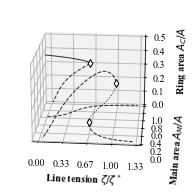

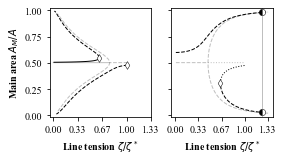

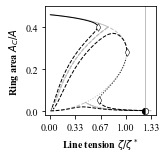

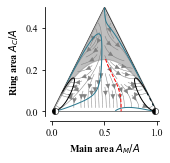

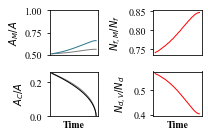

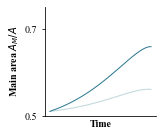

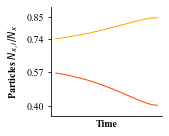

In [88]:
c=0

# Load main and side branches
branch_1 = pd.read_csv(os.path.join(directory, f'Branch_high_density_c_0_1.csv'), header=None)
branch_2 = pd.read_csv(os.path.join(directory, f'Branch_high_density_c_0_2.csv'), header=None)
branch_3 = pd.read_csv(os.path.join(directory, f'Branch_high_density_c_0_3.csv'), header=None)

branch_1[4] = branch_1[4]/asize
branch_2[4] = branch_2[4]/asize
branch_3[4] = branch_3[4]/asize

branch_1 = branch_1[branch_1[4]<4/3*zeta_change]
branch_2 = branch_2[branch_2[4]<4/3*zeta_change]
branch_3 = branch_3[branch_3[4]<4/3*zeta_change]

# Split middle branch by spherical condition
branch_2_upper, branch_2_lower = split_main_branch_shape(branch_2)

# Track if labels have been added
bp_label_added = False
lp_label_added = False

# Define filling for scatter points
scatter_colorstyle = {"BP": 'black', "LP": 'white'}

####################################################################################
# 3D bifurcation diagram
fig_3D = plt.figure(figsize=(5, 3))
ax3D = fig_3D.add_subplot(111, projection='3d')

plot_branch_3D(branch_1, ax3D)
plot_branch_3D(branch_2_upper, ax3D)
plot_branch_3D(branch_2_lower, ax3D)
plot_branch_3D(branch_3, ax3D)

# Viewing angle
ax3D.view_init(elev=20, azim=-85)

# Axis limits and labels
ax3D.set_ylim(0, 1)
ax3D.set_zlim(0, 0.5)
ax3D.set_xticks(xticks)

ax3D.set_xlabel(r"Line tension $\zeta/\zeta^*$", ha='center', fontweight='bold')
ax3D.set_ylabel('Main area $A_M/A$', ha='center', fontweight='bold', labelpad=8)
ax3D.set_zlabel('Ring area $A_C/A$', ha='center', fontweight='bold', labelpad=10)

ax3D.xaxis.set_major_formatter(FuncFormatter(zeta_formatter)) # align zeta scaling

# Save 3D plot **without labels or legend**
plt.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_N_3D.svg'), dpi=300, bbox_inches='tight')
plt.show()

plt.close(fig_3D)

################################################################################################
# 2D bifurcation diagrams and flow diagram FPs
figM, (axM1, axM2) = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
figC, axC = plt.subplots(1, 1, figsize=(2,2))
fig_flow = plt.figure(figsize=(2, 2))
ax_flow = fig_flow.add_subplot(111)

plot_flow(ax_flow, epsilon, kappa*asize, zeta*asize, C0, c, Nf, Nd)

# Plot branches without particles
plot_branch_A_M_simple(main_branch_upper, axM1)
plot_branch_A_M_simple(main_branch_lower, axM2)
plot_branch_A_M_simple(side_branch_1, axM1)
plot_branch_A_M_simple(side_branch_2, axM2)

plot_branch_A_C_simple(main_branch_upper, axC)
plot_branch_A_C_simple(main_branch_lower, axC)
plot_branch_A_C_simple(side_branch_1, axC)
plot_branch_A_C_simple(side_branch_2, axC)

# Plot branches with particles
plot_branch_A_M(branch_1, axM2, ax_flow, x_value = zeta)
plot_branch_A_M(branch_2_upper, axM1, ax_flow, x_value = zeta)
plot_branch_A_M(branch_2_lower, axM2, ax_flow, x_value = zeta)
plot_branch_A_M(branch_3, axM1, ax_flow, x_value = zeta)

plot_branch_A_C(branch_1, axC, x_value = zeta)
plot_branch_A_C(branch_2_upper, axC, x_value = zeta)
plot_branch_A_C(branch_2_lower, axC, x_value = zeta)
plot_branch_A_C(branch_3, axC, x_value = zeta)

# Plot inset
'''
axins = inset_axes(axM1, width="30%", height="40%", loc="upper right")
plot_branch_A_M_simple(main_branch_upper, axins)
plot_branch_A_M_simple(side_branch_1, axins)
plot_branch_A_M(branch_2_upper, axins, ax_flow, 'grey', x_value = zeta, inset = True)
plot_branch_A_M(branch_3, axins, ax_flow, 'grey', x_value = zeta, inset = True)
axins.set_xlim(200, 280)
axins.set_ylim(0.35, 0.65)
axins.set_xticks([])
axins.set_yticks([])
axins.tick_params(labelleft=False, labelbottom=False)
mark_inset(axM1, axins, loc1=2, loc2=4, fc="none", ec="0.5")
axins.axvline(x=zeta, color='grey', alpha = 0.5, lw = 1)
'''

# Labels and limits
axM1.set_ylabel('Main area $A_M/A$', fontweight='bold')
axM1.set_ylim(-0.02, 1)
#axM1.set_xlim(0.001, 4)
axM2.set_ylim(-0.02, 1.02)
#axM2.set_xlim(0.001, 3.5)

axC.set_ylabel('Ring area $A_C/A$', fontweight='bold')
axC.set_ylim(-0.02, 0.5)
#axC.set_xlim(0.001, 3.5)

for ax in [axM1, axM2, axC]:
    ax.grid(False)
    ax.set_xlabel(r"Line tension $\zeta/\zeta^*$", fontweight='bold')
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(FuncFormatter(zeta_formatter)) # align zeta scaling

axM2.axvline(x=zeta, color='grey', alpha = 0.5)
axC.axvline(x=zeta, color='grey', alpha = 0.5)

ax_flow.set_ylim(-0.02, 0.5)
ax_flow.set_xlim(-0.02, 1.02)
trajectory = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '4D_c0.00_nf0.25.csv'), header=None)
ax_flow.plot(trajectory[1].values, trajectory[2].values, color = 'red', linestyle='--', zorder = 4)

#Save figures
figM.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_AM_N_2D.svg'), dpi=300, bbox_inches='tight')
figC.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_AC_N_2D.svg'), dpi=300, bbox_inches='tight')
fig_flow.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_flow_N.svg'), format='svg', dpi=300)
plt.show(figM)
plt.show(figC)
plt.show(fig_flow)
plt.close(figM)
plt.close(figC)
plt.close(fig_flow)

#############################################################################################
# Plot trajectory
# Reference trajectory
trajectory_absence = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '2D.csv'), header=None)
fig, axes = plt.subplots(2, 2, figsize=(3, 2), sharex = True)

# Relative time scale
trajectory[0] = trajectory[0]/max(trajectory[0])
trajectory_absence[0] = trajectory_absence[0]/max(trajectory_absence[0])

# Remove initial equilibration of particle numbers
trajectory = trajectory.iloc[10:]

# Smooth out particle equilibration
trajectory = trajectory.iloc[::20]

axes[0,0].plot(trajectory_absence[0].values, trajectory_absence[1].values, color = 'grey')
axes[1,0].plot(trajectory_absence[0].values, trajectory_absence[2].values, color = 'grey')

axes[0,0].plot(trajectory[0].values, trajectory[1].values, color = AMblue)
axes[1,0].plot(trajectory[0].values, trajectory[2].values, color = 'black')

axes[0,1].plot(trajectory[0].values, trajectory[3].values/Nf, color = 'red')
axes[1,1].plot(trajectory[0].values, 1-trajectory[4].values/Nd, color = 'red')

axes[1,0].set_xticks([])
axes[1,0].set_xlabel('Time', fontweight='bold')
axes[1,1].set_xticks([])
axes[1,1].set_xlabel('Time', fontweight='bold')

axes[0, 0].set_ylim([0.5,1])
axes[1, 0].set_ylim([0,0.26])

axes[0, 0].set_ylabel(r'$A_M/A$', fontweight='bold')
axes[1, 0].set_ylabel(r'$A_C/A$', fontweight='bold')
axes[0, 1].set_ylabel(r'$N_{f,M}/N_f$', fontweight='bold')
axes[1,1].set_ylabel(r'$N_{d,V}/N_d$', fontweight='bold')

plt.tight_layout()

plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_large.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

############ One figure each
fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(trajectory[0].values, trajectory[1].values, color = AMblue)
ax.plot(trajectory_absence[0].values, trajectory_absence[1].values, color = AMblue, alpha = 0.3)
ax.set_xticks([])
ax.set_xlabel('Time', fontweight='bold')
ax.set_ylabel(r'Main area $A_M/A$', fontweight='bold')
ax.set_yticks([0.5, 0.7])
ax.set_ylim([0.5, 0.75])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_large_simple.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(trajectory[0].values, trajectory[3].values/Nf, color = 'orange')
ax.plot(trajectory[0].values, 1-trajectory[4].values/Nd, color = 'orangered')
ax.set_yticks(np.round(np.array([trajectory[3].values[0], trajectory[3].values[-1], Nd-trajectory[4].values[0], Nd-trajectory[4].values[-1]])*2/N, 2))
ax.set_xticks([])
ax.set_xlabel('Time', fontweight='bold')
ax.set_ylabel(r'Particles $N_{x,i}/N_x$', fontweight='bold')
ax.set_ylim([0.35, 0.9])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(FIGURES, 'Paper', 'number_trajectory_large_simple.svg'), format='svg', dpi=300)
plt.show()
plt.close(fig)

## Negatively curved particles

C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/152237170.py:14: RuntimeWarning: invalid value encountered in log
  eq1 = -np.log((gamma * N_fM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_f - N_fM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/152237170.py:15: RuntimeWarning: invalid value encountered in log
  eq2 = -np.log((N_dM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_d - N_dM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/152237170.py:23: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  N_fM_equi, N_dM_equi = fsolve(equations, [N_fM_guess, N_dM_guess])


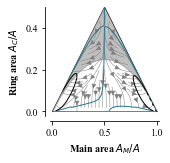

In [ ]:
N = 1/10
Nf = N/2
Nd = N/2
c = - 0.25

fig_flow = plt.figure(figsize=(2, 2))
ax_flow = fig_flow.add_subplot(111)

plot_flow(ax_flow, epsilon, kappa*asize, zeta*asize, C0, c, Nf, Nd)

fig_flow.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_neg_c.svg'), format='svg', dpi=300)
plt.show(fig_flow)
plt.close(fig_flow)

C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/3387796328.py:250: RuntimeWarning: invalid value encountered in log
  eq1 = -np.log((gamma * N_fM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_f - N_fM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/3387796328.py:251: RuntimeWarning: invalid value encountered in log
  eq2 = -np.log((N_dM_dyn * (1 - A_M - N_V_dyn)) / ((A_M - N_M_dyn) * (N_d - N_dM_dyn))) + 4 * k * c * ((R_inv(A_C, A_M) - C0 - C_M) - (R_inv(A_C, 1 - A_M) - C0 - C_V))
C:\Users\lenovo\AppData\Local\Temp/ipykernel_25572/3387796328.py:259: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  N_fM_equi, N_dM_equi = fsolve(equations, [N_fM_guess, N_dM_guess]) # Error message for the two nullclines aligning


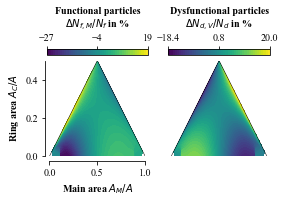

In [96]:
#################################################################################################
# Plot change in number equilibrium in a separate figure
fig_nu, (ax_nu1, ax_nu2) = plt.subplots(1, 2, figsize=(4, 2.2), sharey = True)  # New figure with requested size

N_fM_grid, N_dM_grid = vectorized_find_equilib(A_M_grid, A_C_grid, Nf, Nd, epsilon, zeta*asize, kappa*asize, C0, c) #the free energy is rescaled by a/A
############### The warning comes for small A_C or A_M near 0 or 1: numerical solutions are not found (runs into invalid regions)

# Convert possible None values to NaN for consistency
N_fM_grid = np.where(np.isnan(N_fM_grid), np.nan, N_fM_grid)
N_dM_grid = np.where(np.isnan(N_dM_grid), np.nan, N_dM_grid)

# --- fill sentinel cells with nearest neighbour ---
def fill_nearest(arr):
    # Masking empty entries
    mask = (arr == 0) | np.isnan(arr)
    # Masking invalid geometries
    mask_geo = (A_C_grid < A_M_grid) & (A_C_grid < (1 - A_M_grid))
    
    mask_combi = mask & mask_geo
    
    if not mask_combi.any():
        return arr
    nearest = distance_transform_edt(
        mask_combi, return_distances=False, return_indices=True
    )
    return arr[tuple(nearest)]

N_fM_grid = fill_nearest(N_fM_grid)
N_dM_grid = fill_nearest(N_dM_grid)
N_fM_grid = fill_nearest(N_fM_grid)
N_dM_grid = fill_nearest(N_dM_grid)

# Plot heatmaps in ax_nu1 and ax_nu2 with shared color scale
cf1 = ax_nu1.contourf(A_M_grid, A_C_grid, N_fM_grid, cmap='viridis', levels=50, antialiased=False)
cf2 = ax_nu2.contourf(A_M_grid, A_C_grid, -N_dM_grid, cmap='viridis', levels=50, antialiased=False)

for cf in cf1.collections:
    cf.set_rasterized(True)
    
for cf in cf2.collections:
    cf.set_rasterized(True)

# Add boundaries
for ax in [ax_nu1, ax_nu2]:
    ax.plot(np.linspace(0, 0.5, 1000), np.linspace(0, 0.5, 1000), linewidth=0.5, color='black', zorder = 1)
    ax.plot(np.linspace(0.5, 1, 1000), 1 - np.linspace(0.5, 1, 1000), linewidth=0.5, color='black', zorder = 1)
    ax.plot(np.linspace(0, 1, 1000), np.zeros(1000), linewidth=0.5, color='black', zorder = 1)
    ax.set_xlabel('Main area $A_M/A$', fontweight='bold')

floating_axes(ax_nu1)
ax_nu2.axis('off')

ax_nu1.set_ylabel('Ring area $A_C/A$', ha='center', fontweight='bold')

# Colorbars with the same scaling
cbar1 = fig_nu.colorbar(cf1, ax=ax_nu1, orientation = 'horizontal', location = 'top')
cbar2 = fig_nu.colorbar(cf2, ax=ax_nu2, orientation = 'horizontal', location = 'top')

cbar1.set_label(label='Functional particles\n' +r'$\Delta N_{f,M}/N_f$ in %', fontweight = 'bold')
cbar2.set_label(label='Dysfunctional particles\n' +r'$\Delta N_{d,V}/N_d$ in %', fontweight='bold')
for cb in (cbar1, cbar2):
    vmin, vmax = cb.mappable.get_clim()
    cb.set_ticks(np.linspace(vmin, vmax, 3))
    cb.solids.set_rasterized(True) 
    cb.solids.set_rasterized(True)

ax_nu1.set_aspect(2)
ax_nu2.set_aspect(2)

# Save new figure
plt.savefig(os.path.join(FIGURES, 'Paper', 'number_change_neg_c.svg'), format='svg', dpi=300)